In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv('VMD Data.csv')
A = df['T'].values
B = df['P'].values
C = df['Q'].values
D = df['C'].values

flux_true = df['F'].values
sec_true = df['SEC'].values

def build_rsm_matrix(A,B,C,D):
    X = pd.DataFrame({
        'A':A,
        'B':B,
        'C':C,
        'D':D,
        'A2':A**2,
        'B2':B**2,
        'C2':C**2,
        'D2':D**2,
        'AB':A*B,
        'AC':A*C,
        'AD':A*D,
        'BC':B*C,
        'BD':B*D,
        'CD':C*D
    })
    X=sm.add_constant(X)
    return X

X = build_rsm_matrix(A,B,C,D)

model_flux = sm.OLS(flux_true,X).fit()
model_sec = sm.OLS(sec_true,X).fit()

print(model_flux.summary())
print(model_sec.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.991
Method:                 Least Squares   F-statistic:                     248.3
Date:                Sat, 13 Dec 2025   Prob (F-statistic):           5.68e-16
Time:                        13:06:14   Log-Likelihood:                -36.732
No. Observations:                  31   AIC:                             103.5
Df Residuals:                      16   BIC:                             125.0
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         12.4521    263.819      0.047      0.9

In [72]:
flux_pred = model_flux.predict(X)
sec_pred = model_sec.predict(X)

def regression_report(y_true,y_pred,label=''):
    mae = mean_absolute_error(y_true,y_pred)
    mse = mean_squared_error(y_true,y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true,y_pred)

    print(f"R²    : {r2:.4f}")
    print(f"RMSE  : {rmse:.4f}")
    print(f"MAE   : {mae:.4f}")
    
    return r2, rmse, mae

r2_f, rmse_f, mae_f = regression_report(flux_true,flux_pred,label = "Flux(RSM)")
r2_s, rmse_s, mae_s = regression_report(sec_true,sec_pred,label = "SEC(RSM)")



R²    : 0.9954
RMSE  : 0.7913
MAE   : 0.6561
R²    : 0.9765
RMSE  : 0.3167
MAE   : 0.2717


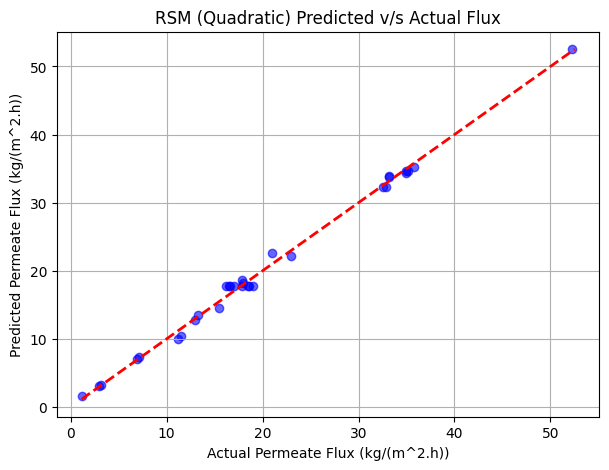

In [73]:
plt.figure(figsize = (7,5))
plt.scatter(flux_true,flux_pred, c = 'blue', alpha = 0.6)
mn = min(flux_true.min(),flux_pred.min())
mx = max(flux_true.max(),flux_pred.max())
plt.plot([mn,mx],[mn,mx],'r--',lw=2)
plt.xlabel('Actual Permeate Flux (kg/(m^2.h))')
plt.ylabel('Predicted Permeate Flux (kg/(m^2.h))')
plt.title('RSM (Quadratic) Predicted v/s Actual Flux')
plt.grid(True)
plt.show()

In [74]:
columns_order = X.columns

def predict_flux_sec(T,P,Q,C):
    A_n = np.array([T])
    B_n = np.array([P])
    C_n = np.array([Q])
    D_n = np.array([C])

    data = {
        'A': A_n, 'B': B_n, 'C': C_n, 'D': D_n,
        'A2': A_n**2, 'B2': B_n**2, 'C2': C_n**2, 'D2': D_n**2,
        'AB': A_n*B_n, 'AC': A_n*C_n, 'AD': A_n*D_n,
        'BC': B_n*C_n, 'BD': B_n*D_n, 'CD': C_n*D_n
    }
    
    X_n = pd.DataFrame(data)

    X_n['const'] = 1.0
    X_n = X_n[columns_order]

    flux_n = float(model_flux.predict(X_n)[0])
    sec_n = float(model_sec.predict(X_n)[0])

    return flux_n, sec_n

T_test, P_test, Q_test, C_test = 55, 710, 6, 70
print(predict_flux_sec(T_test,P_test,Q_test,C_test))


(17.692105772376333, 7.580787249167682)


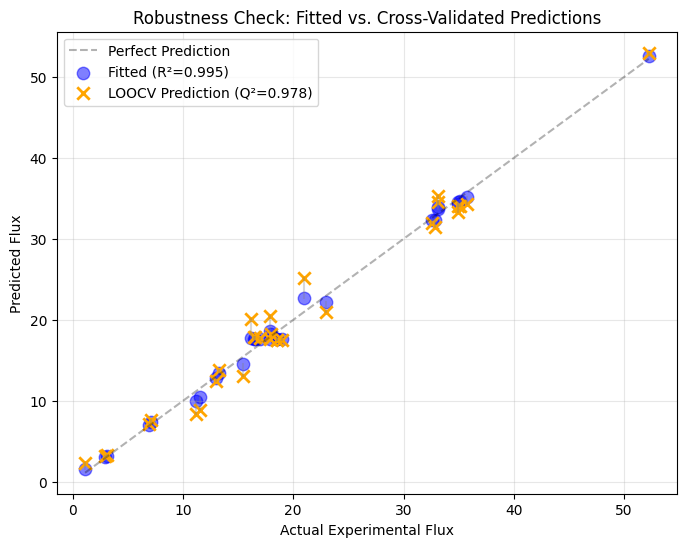

In [75]:
import matplotlib.pyplot as plt
from sklearn.model_selection import LeaveOneOut

# 1. Helper to get LOOCV predictions list
def get_loocv_preds(X, y):
    X_safe = X.reset_index(drop=True)
    y_safe = np.array(y).flatten()
    
    # Store just the prediction for the left-out point
    preds = [sm.OLS(y_safe[train], X_safe.iloc[train]).fit().predict(X_safe.iloc[test]).iloc[0] 
             for train, test in LeaveOneOut().split(X_safe)]
    return np.array(preds)

# 2. Get the data
flux_fitted = model_flux.predict(X)      # The "Training" fit (Blue)
flux_cv = get_loocv_preds(X, flux_true)  # The "Testing" prediction (Orange)

# 3. Plot
plt.figure(figsize=(8, 6))

# Plot the "Perfect Fit" line
mn, mx = flux_true.min(), flux_true.max()
plt.plot([mn, mx], [mn, mx], 'k--', alpha=0.3, label='Perfect Prediction')

# Scatter 1: The Model Fitting (Standard R2)
plt.scatter(flux_true, flux_fitted, c='blue', alpha=0.5, s=80, label=f'Fitted (R²={model_flux.rsquared:.3f})')

# Scatter 2: The Cross-Validation (Robustness Q2)
plt.scatter(flux_true, flux_cv, c='orange', marker='x', s=80, lw=2, label=f'LOOCV Prediction (Q²={q2_flux:.3f})')

# Connect the dots to show stability (Optional visual aid)
# This draws a line between the "fitted" and "cross-validated" version of each point
for i in range(len(flux_true)):
    plt.plot([flux_true[i], flux_true[i]], [flux_fitted[i], flux_cv[i]], 'gray', alpha=0.3)

plt.xlabel('Actual Experimental Flux')
plt.ylabel('Predicted Flux')
plt.title('Robustness Check: Fitted vs. Cross-Validated Predictions')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()